In [ ]:
# !pip install tensorflow
import numpy as np
import collections
import math
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
#--------------------------
# 1. Paths and parameters
#--------------------------
data_dir = "/kaggle/input/datasets/shuvammaity40/plant-village-sp-mohanty/SP_Mohanty/Bell Pepper"
img_size = (224, 224)
batch_size = 32
seed = 42

#------------------------------------------------
# 2. Load full dataset as unbatched and shuffled
#------------------------------------------------
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=seed,
    image_size=img_size,
    batch_size=None,
    shuffle=True
)

total_images = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * total_images)
val_size = int(0.15 * total_images)

#----------------------------
# 3. Split the shuffled pool
#----------------------------
train_ds = full_ds.take(train_size).batch(batch_size)
remaining = full_ds.skip(train_size)
val_ds = remaining.take(val_size).batch(batch_size)
test_ds = remaining.skip(val_size).batch(batch_size)

Found 2475 files belonging to 2 classes.


In [ ]:
# -------------------------------
# 4. Performance optimizations
# -------------------------------
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# -------------------------------
# 5. Sanity check
# -------------------------------
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 55
Val batches: 12
Test batches: 12


In [ ]:
class_names=full_ds.class_names
class_names

['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']

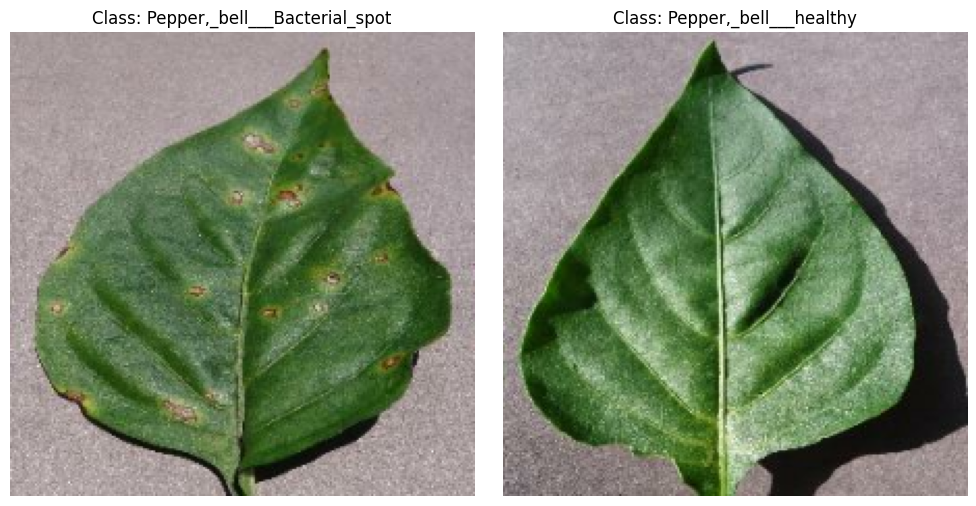

In [ ]:
# Extract one sample image per class
found_images = {}
class_names = full_ds.class_names

for image, label in full_ds:
    label_idx = label.numpy()
    if label_idx not in found_images:
        # Convert to uint8 for proper plt.imshow rendering
        found_images[label_idx] = image.numpy().astype("uint8")

    # Stop once we have an image for every class
    if len(found_images) == len(class_names):
        break

# Plotting : 2 images per row
num_classes = len(class_names)
cols = 2
rows = math.ceil(num_classes / cols)

plt.figure(figsize=(10, 5 * rows))

for i, (idx, img) in enumerate(sorted(found_images.items())):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_names[idx]}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def get_class_distribution(dataset, class_names):
    """Counts the number of images per class in a batched tf.data.Dataset."""
    counts = collections.Counter()
    # Iterating through the batches
    for _, labels in dataset:
        # labels is a tensor of shape (batch_size,)
        counts.update(labels.numpy())

    # Map indices back to class names
    return {class_names[i]: counts[i] for i in range(len(class_names))}

# Calculate distributions for each set

train_dist = get_class_distribution(train_ds, class_names)
val_dist = get_class_distribution(val_ds, class_names)
test_dist = get_class_distribution(test_ds, class_names)

# Print the formatted results
print(f"{'Class Name':<30} | {'Train':<7} | {'Val':<7} | {'Test':<7}")
print("-" * 60)
for name in class_names:
    print(f"{name:<30} | {train_dist.get(name, 0):<7} | {val_dist.get(name, 0):<7} | {test_dist.get(name, 0):<7}")

Class Name                     | Train   | Val     | Test   
------------------------------------------------------------
Pepper,_bell___Bacterial_spot  | 701     | 146     | 134    
Pepper,_bell___healthy         | 1031    | 225     | 238    


In [ ]:
# Total number of images in the training set
total_train_images = sum(train_dist.values())
num_classes = len(class_names)

# Formula: total / (num_classes * class_count)
class_weight = {}
for i, name in enumerate(class_names):
    count = train_dist.get(name, 1) # avoid division by zero
    weight = total_train_images / (num_classes * count)
    class_weight[i] = weight

print("Calculated Class Weights:")
for i, name in enumerate(class_names):
    print(f"{name}: {class_weight[i]:.2f}")

Calculated Class Weights:
Pepper,_bell___Bacterial_spot: 1.24
Pepper,_bell___healthy: 0.84


In [ ]:
normalization = layers.Rescaling(1./255)

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [ ]:
model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    normalization,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_bell_pepper_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=class_weight,  # <--- CRITICAL STEP
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6343 - loss: 0.8023
Epoch 1: val_accuracy improved from -inf to 0.93801, saving model to best_bell_pepper_cnn.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.6363 - loss: 0.7979 - val_accuracy: 0.9380 - val_loss: 0.1779
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9105 - loss: 0.3047
Epoch 2: val_accuracy did not improve from 0.93801
55/55 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9105 - loss: 0.3051 - val_accuracy: 0.9191 - val_loss: 0.2181
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8687 - loss: 0.3462
Epoch 3: val_accuracy did not improve from 0.93801
55/55 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8692 - loss: 0.3457 - val_accuracy: 0.9191 - val_loss: 0.2168
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9043 - loss: 0.4180
Epoch 4: val_accuracy improved from 0.93801 to 0.96226, saving model to best_bell_pepper_cnn.keras
55/55 ━━━━━━━━━━━━━

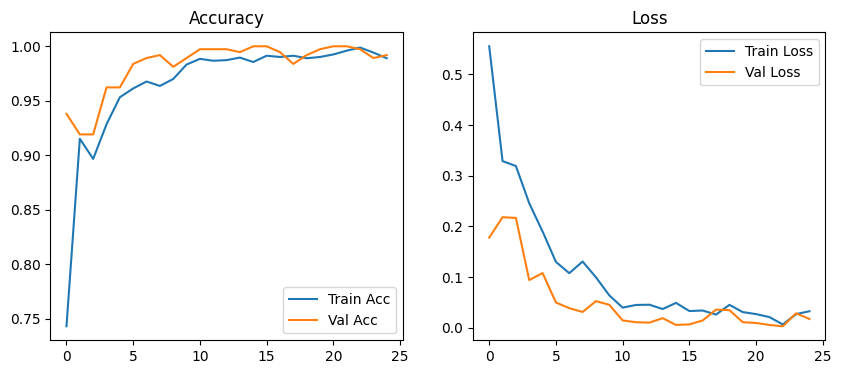

In [ ]:
# --- Plot training history ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
best_model = tf.keras.models.load_model("best_bell_pepper_cnn.keras")

In [ ]:
# Calculate Training Metrics
train_loss, train_acc = best_model.evaluate(train_ds)
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Train Loss: {train_loss}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 512ms/step - accuracy: 0.9986 - loss: 0.0184
Train Accuracy: 99.77%
Train Loss: 0.014950939454138279%


In [ ]:
# Calculate Validation Metrics
val_loss, val_acc = best_model.evaluate(val_ds)
print(f"Val Accuracy: {val_acc*100:.2f}%")
print(f"Val Loss: {val_loss}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 506ms/step - accuracy: 1.0000 - loss: 0.0062
Val Accuracy: 100.00%
Val Loss: 0.005626846104860306%


In [ ]:
# Calculate Test Metrics
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 508ms/step - accuracy: 1.0000 - loss: 0.0070
Test Accuracy: 100.00%
Test Loss: 0.006972994189709425%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


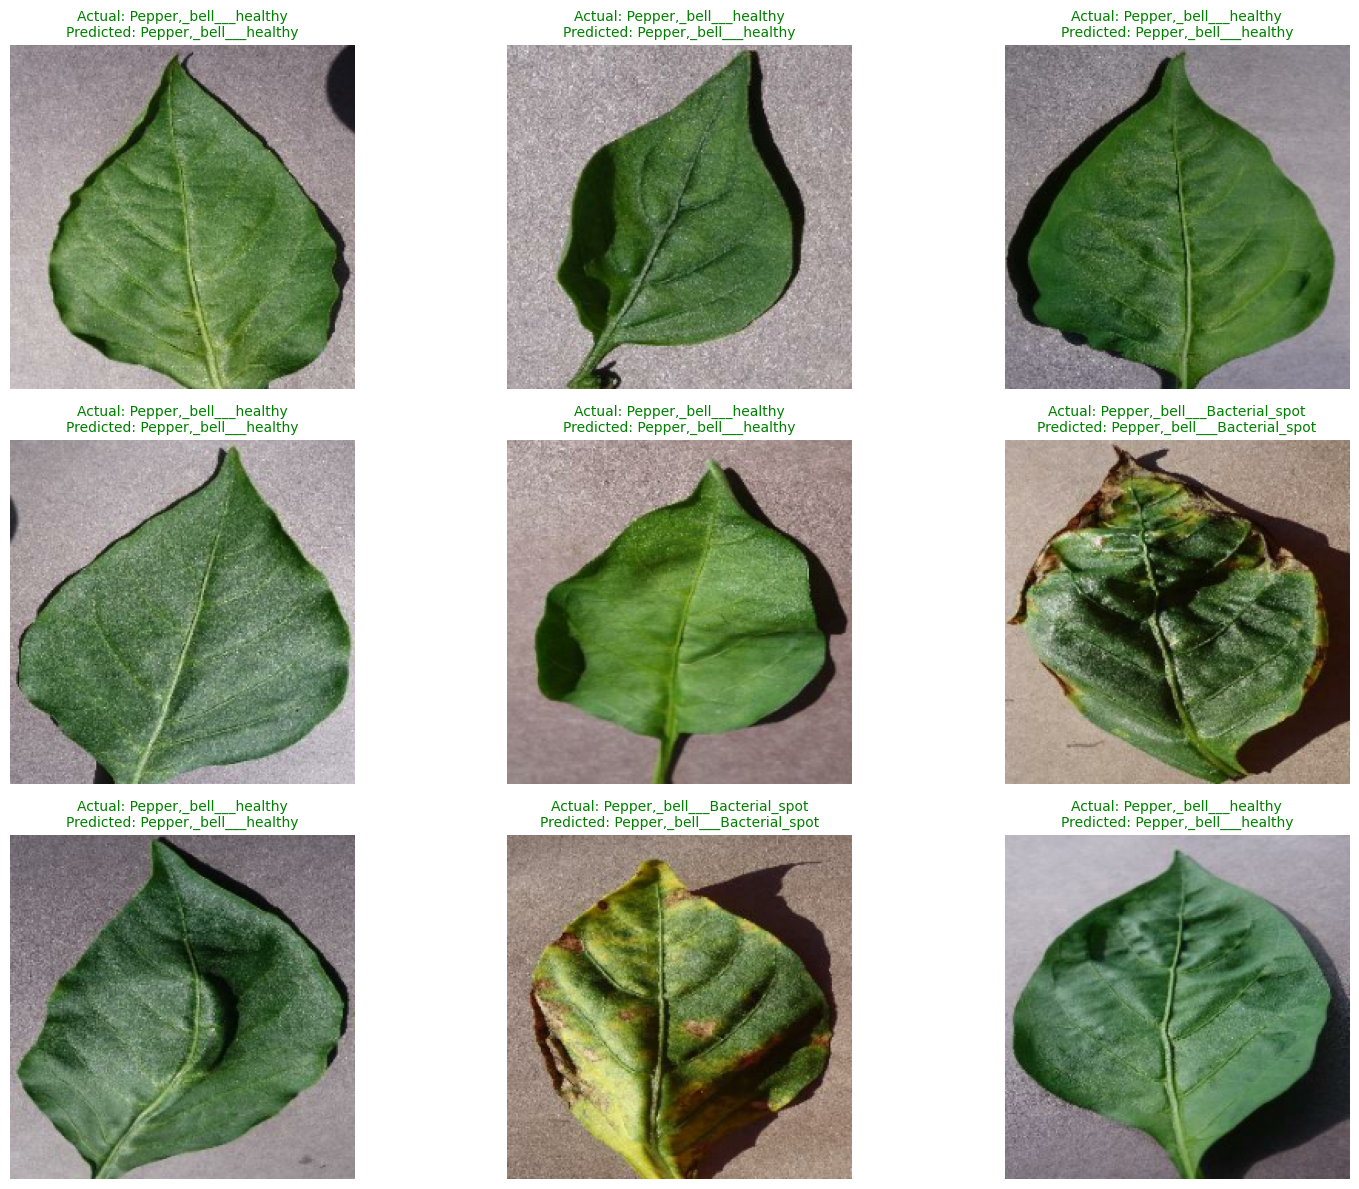

In [ ]:
# 1. Take one batch from the test set
for images, labels in test_ds.take(1):
    # 2. Generate predictions for the entire batch
    # This returns a 2D array of probabilities (one row per image)
    predictions = model.predict(images)

    plt.figure(figsize=(16, 12))

    # 3. Plot the first 9 images from this batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Display the image (handle uint8 conversion)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get the index of the highest probability
        pred_label_idx = np.argmax(predictions[i])
        actual_label_idx = labels[i].numpy()

        # Set color: Green if correct, Red if wrong
        color = 'green' if pred_label_idx == actual_label_idx else 'red'

        plt.title(
            f"Actual: {class_names[actual_label_idx]}\n"
            f"Predicted: {class_names[pred_label_idx]}",
            color=color, fontsize=10
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Extract true labels from the test_ds
print("Extracting true labels...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Get model predictions (probabilities)
print("Generating predictions...")
y_probs = model.predict(test_ds)

# Convert probabilities to class indices
y_pred = np.argmax(y_probs, axis=1)

# Generate and print the Classification Report
print("\n" + "="*20 + " CLASSIFICATION REPORT " + "="*20)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Extracting true labels...
Generating predictions...
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 515ms/step

==================== CLASSIFICATION REPORT ====================
                               precision    recall  f1-score   support

Pepper,_bell___Bacterial_spot       1.00      1.00      1.00       134
       Pepper,_bell___healthy       1.00      1.00      1.00       238

                     accuracy                           1.00       372
                    macro avg       1.00      1.00      1.00       372
                 weighted avg       1.00      1.00      1.00       372



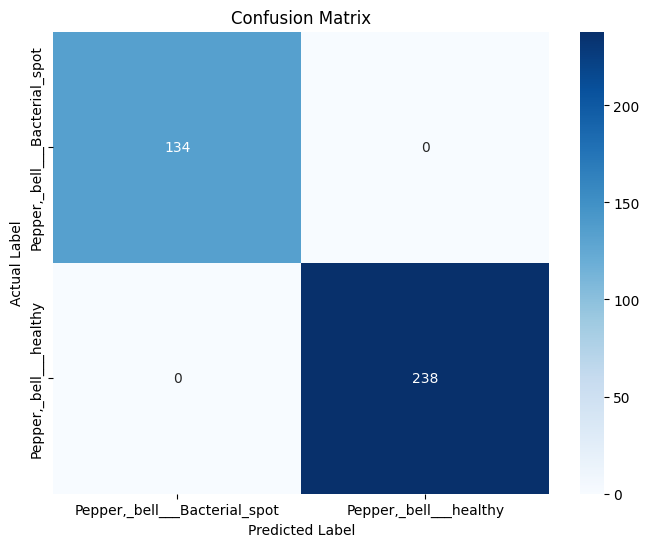

In [ ]:
# Plotting a Confusion Matrix for better visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()